In [1]:
import pandas as pd
print("pandas installed successfully")

pandas installed successfully


In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (891, 12)


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
df["Age"].mean()

np.float64(29.69911764705882)

In [ ]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


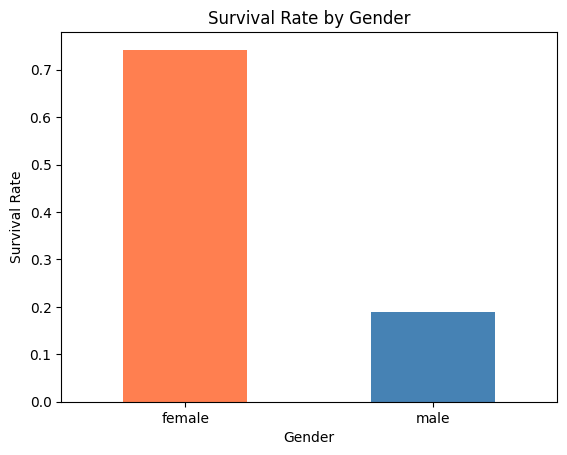

In [ ]:
import matplotlib.pyplot as plt

# survival by gender
survival_by_gender = df.groupby("Sex")["Survived"].mean()

survival_by_gender.plot(kind="bar", color=["coral", "steelblue"])
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print("Ready! Shape:", df.shape)

Ready! Shape: (891, 12)


In [ ]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()
print(survival_by_class)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


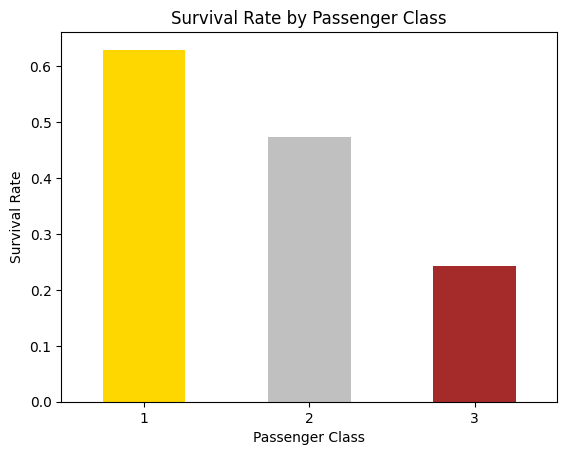

In [ ]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(kind="bar", color=["gold", "silver", "brown"])
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.xticks(rotation=0)
plt.show()

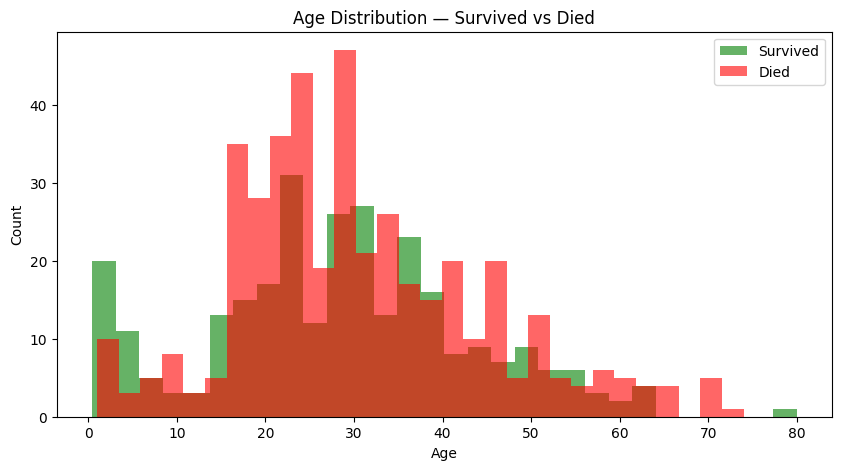

In [ ]:
survived = df[df["Survived"] == 1]["Age"]
died = df[df["Survived"] == 0]["Age"]

plt.figure(figsize=(10,5))
plt.hist(survived, bins=30, alpha=0.6, color="green", label="Survived")
plt.hist(died, bins=30, alpha=0.6, color="red", label="Died")
plt.title("Age Distribution — Survived vs Died")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
print("Average age of survivors:", df[df["Survived"]==1]["Age"].mean())
print("Average age of died:", df[df["Survived"]==0]["Age"].mean())

Average age of survivors: 28.343689655172415
Average age of died: 30.62617924528302


In [ ]:
# did children survive more?
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100],
                         labels=["Child","Teen","YoungAdult","Adult","Senior"])

df.groupby("AgeGroup")["Survived"].mean()

/tmp/ipykernel_1442/951879522.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
YoungAdult,0.382682
Adult,0.400000
Senior,0.227273


In [ ]:
best = df.groupby(["Sex", "Pclass"])["Survived"].mean()
print(best)

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


In [ ]:
print("=" * 50)
print("TITANIC DATASET — EDA REPORT")
print("=" * 50)
print(f"\nTotal Passengers: {len(df)}")
print(f"Survivors: {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"Deaths: {(df['Survived']==0).sum()} ({(df['Survived']==0).mean()*100:.1f}%)")
print("\n--- KEY INSIGHTS ---")
print(f"1. Female survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"   Male survival rate: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"\n2. 1st class survival: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"   3rd class survival: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"\n3. Best combination (Female 1st class): {df[(df['Sex']=='female') & (df['Pclass']==1)]['Survived'].mean()*100:.1f}%")
print(f"   Worst combination (Male 3rd class): {df[(df['Sex']=='male') & (df['Pclass']==3)]['Survived'].mean()*100:.1f}%")
print("\n" + "=" * 50)

TITANIC DATASET — EDA REPORT

Total Passengers: 891
Survivors: 342 (38.4%)
Deaths: 549 (61.6%)

--- KEY INSIGHTS ---
1. Female survival rate: 74.2%
   Male survival rate: 18.9%

2. 1st class survival: 63.0%
   3rd class survival: 24.2%

3. Best combination (Female 1st class): 96.8%
   Worst combination (Male 3rd class): 13.5%



In [ ]:
# ==============================================
# TITANIC DATASET — EXPLORATORY DATA ANALYSIS
# Author: Mohamed Suhail
# Date: April 2026
# Tools: Python, Pandas, Matplotlib
# ==============================================

In [2]:
# Load the dataset from online source
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Check shape — rows and columns
print("Shape:", df.shape)

Shape: (891, 12)


In [3]:
# Find missing values in each column
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
# Survival rate by gender — key insight
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908
